In [1]:
# HIDDEN
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

### Regression line vs other lines

In [2]:
def standard_units(arr):
    """ Converts an array to standard units """
    return (arr - np.average(arr))/np.std(arr)

def correlation(t, x, y):
    """ Computes correlation: t is a table, and x and y are column names """
    x_standard = standard_units(t.column(x))
    y_standard = standard_units(t.column(y))
    return np.average(x_standard * y_standard)

def slope(t, x, y):
    """ Computes the slope of the regression line, like correlation above """
    r = correlation(t, x, y)
    y_sd = np.std(t.column(y))
    x_sd = np.std(t.column(x))
    return r * y_sd / x_sd

def intercept(t, x, y):
    """ Computes the intercept of the regression line, like slope above """
    x_mean = np.mean(t.column(x))
    y_mean = np.mean(t.column(y))
    return y_mean - slope(t, x, y)*x_mean

def fitted_values(t, x, y):
    """Return an array of the regression estimates (predictions) at all the x values"""
    a = slope(t, x, y)
    b = intercept(t, x, y)
    return a*t.column(x) + b

## Residuals

Residual is the name for the error in the regression estimate for each point on the regression line.

To calculate the residual:

= observed y - regression estimate of y

= observed y - height of regression line at x

= vertical distance between the point and the best line


In [3]:
#2016 data about different voting districts throughout the US. 
demographics = Table.read_table('district_demographics2016.csv')
demographics.show(3)

State,District,Median Income,Percent voting for Clinton,College%
Alabama,"Congressional District 1 (115th Congress), Alabama",47083,34.1,24
Alabama,"Congressional District 2 (115th Congress), Alabama",42035,33,21.8
Alabama,"Congressional District 3 (115th Congress), Alabama",46544,32.3,22.8


In [4]:
# COMPLETE: We will focus on the median income of that district and what percent of voters attended college.  
demographics_new = demographics.select('Median Income', 'College%')

demographics_new.show(5)

Median Income,College%
47083,24
42035,21.8
46544,22.8
41110,17
51690,30.3


In [5]:
# Run to declare a function that finds the residual for each data point. 
def residuals(t, x, y):
    predictions = fitted_values(t, x, y)
    return t.column(y) - predictions

***QUESTION: From the completed code below, why are some values negative and other positive?***



In [7]:
# COMPLETE: Create a table that adds the fitted value (from the regression line) and the residual created by that value.
demographics_new = demographics_new.with_columns(
    'Fitted Value', fitted_values(demographics_new, 'College%', 'Median Income'),
    'Residual', residuals(demographics_new, 'College%', 'Median Income')
)
demographics_new

Median Income,College%,Fitted Value,Residual
47083,24,51299.4,-4216.42
42035,21.8,48503.9,-6468.87
46544,22.8,49774.6,-3230.58
41110,17,42404.5,-1294.51
51690,30.3,59304.8,-7614.84
61413,36.7,67437.3,-6024.33
34664,19.4,45454.2,-10790.2
76440,29.6,58415.3,18024.7
50537,24.5,51934.8,-1397.77
49072,34,64006.4,-14934.4


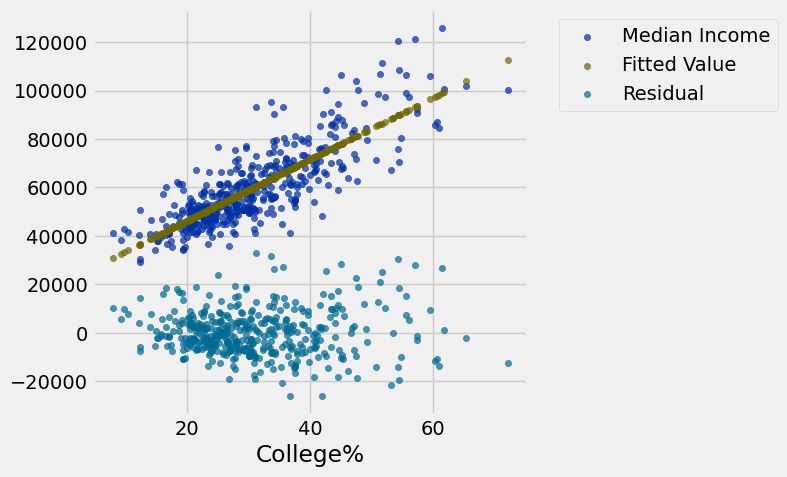

In [9]:
# COMPLETE: View the residuals as a scatter compared to the data scatter. 

demographics_new.scatter('College%')

***QUESTION: Where are the residuals centered around? Why?***



In [10]:
def plot_residuals(t, x, y):
    tbl = t.with_columns(
        'Fitted', fitted_values(t, x, y),
        'Residual', residuals(t, x, y)
    )
    tbl.select(x, y, 'Fitted').scatter(0)
    tbl.scatter(x, 'Residual')

***QUESTION: What are some characteristics you notice about the residuals in the graphs below?***



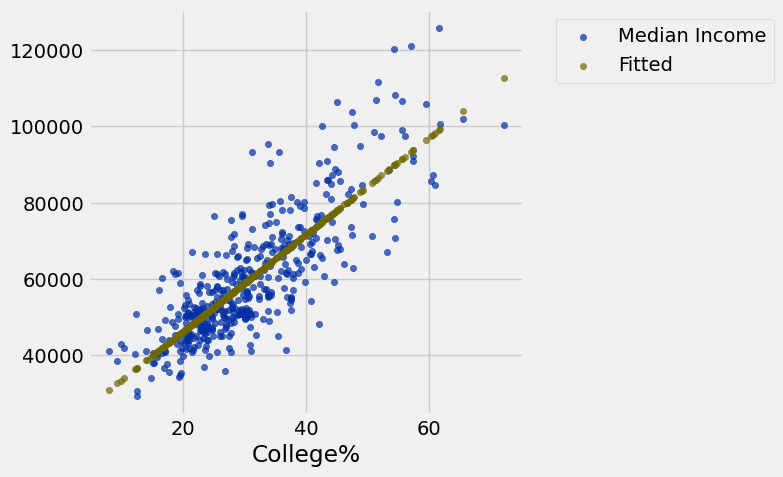

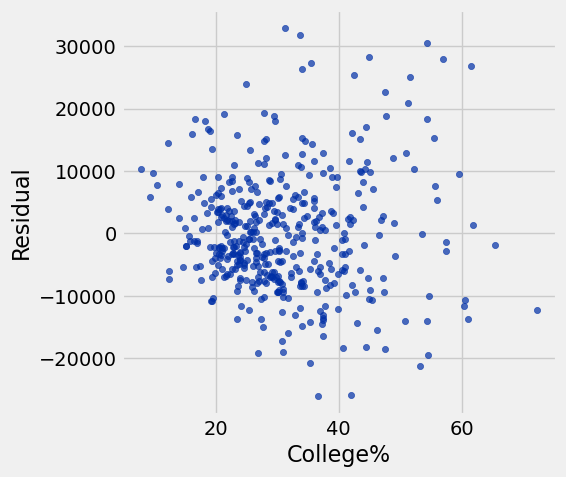

In [13]:
# Plotting the residuals on a separate scatter. 
plot_residuals(demographics, 'College%', 'Median Income')

***QUESTION: Are you noticing similar characteristics in the residual plot below?***



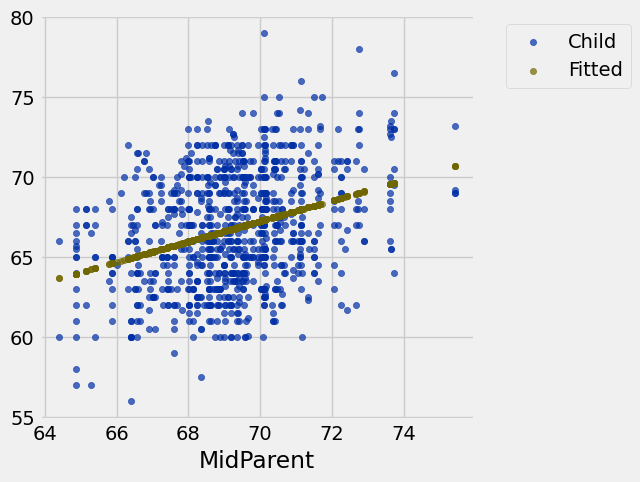

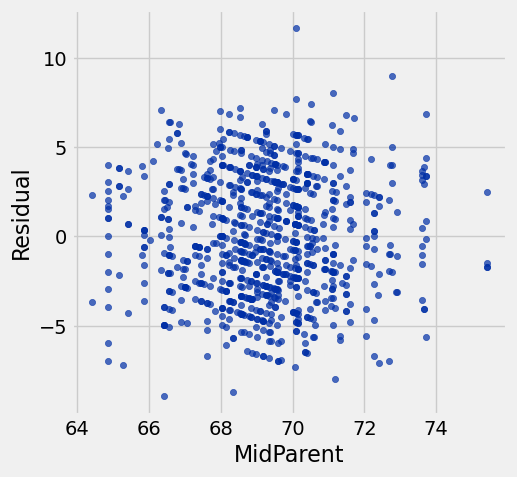

In [14]:
# View the data and residuals of a comparison between average parent's height and their child's height. 
galton = Table.read_table('heights.csv')

heights = Table().with_columns(
    'MidParent', galton.column('midparentHeight'),
    'Child', galton.column('childHeight')
    )
plot_residuals(heights, 'MidParent', 'Child')

## Dugongs ##

Dugongs are a marine animal related to the manatee. There are declining in numbers so ecologist are monitoring them. 
Since they cannot precisely measure how old they are, they want to know if they can predict their age if they  measure how long they are. 


In [15]:
dugong = Table.read_table('dugong.csv')
dugong.show(5)

Length,Age
1.8,1
1.85,1.5
1.87,1.5
1.77,1.5
2.02,2.5


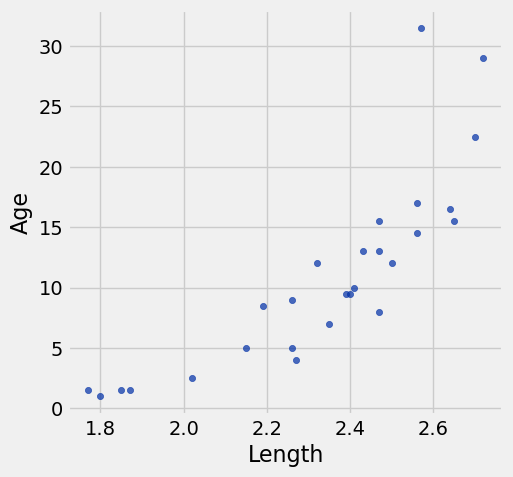

In [16]:
# COMPLETE: Generate a scatter comparing Length and Age

dugong.scatter('Length')

In [17]:
# COMPLETE: Find r for the Length and Age.

correlation(dugong, 'Length', 'Age')

0.82964745549057139

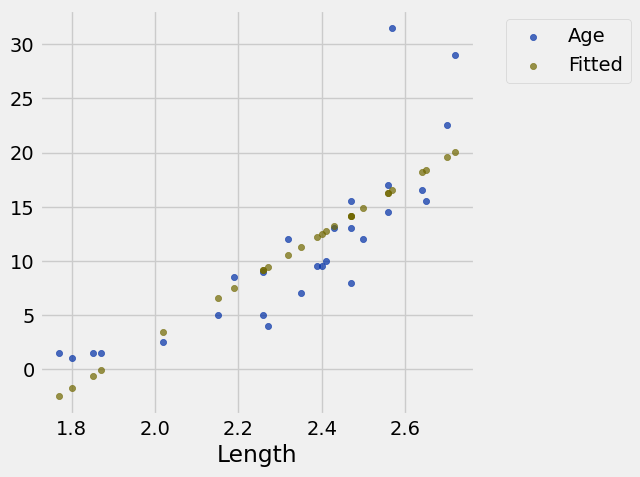

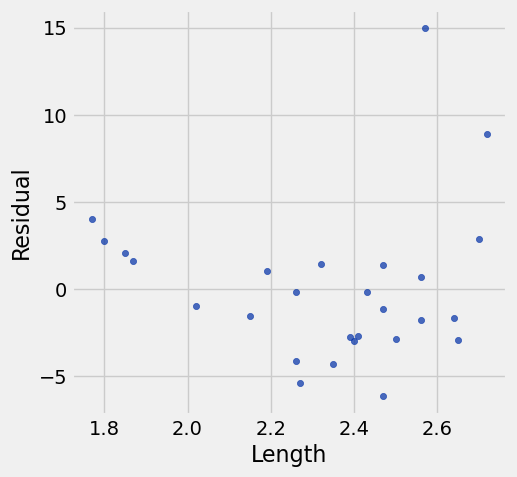

In [18]:
plot_residuals(dugong, 'Length', 'Age')

***QUESTION: What do you notice about the data compared to the Regression Line?***



***QUESTION: What do you notice about the residual plot?***



***QUESTION: What might this indicate?***



# US Women

In [21]:
# Import the table on US women. This displays the average weight for women in the given height category. 
us_women = Table.read_table('us_women.csv')
us_women.show(5)

height,ave weight
58,115
59,117
60,120
61,123
62,126


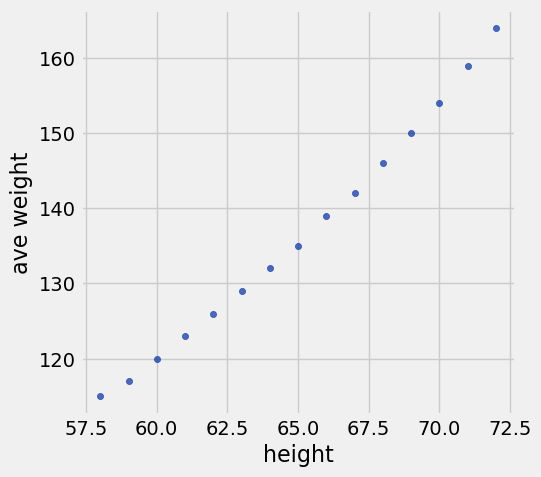

In [20]:
# COMPLETE: Generate a scatter plot of the data

us_women.scatter('height')

***QUESTION: Why is this so linear? What type of correlation is this?***

In [22]:
# COMPLETE: Find r for height and ave weight.

correlation(us_women, 'height', 'ave weight')

0.99549476778421608

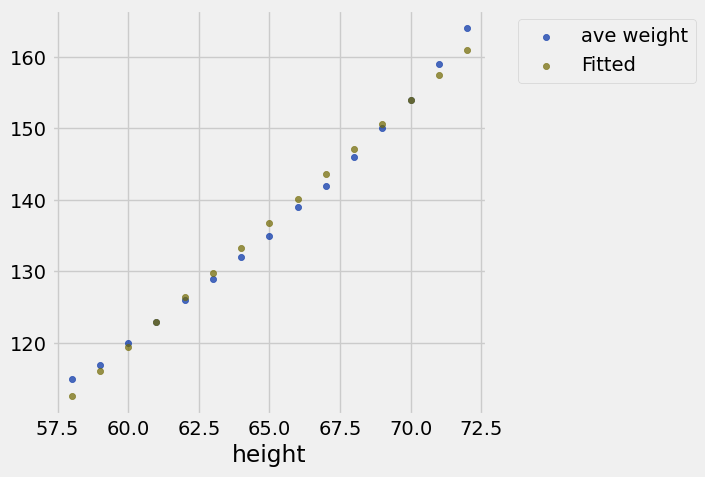

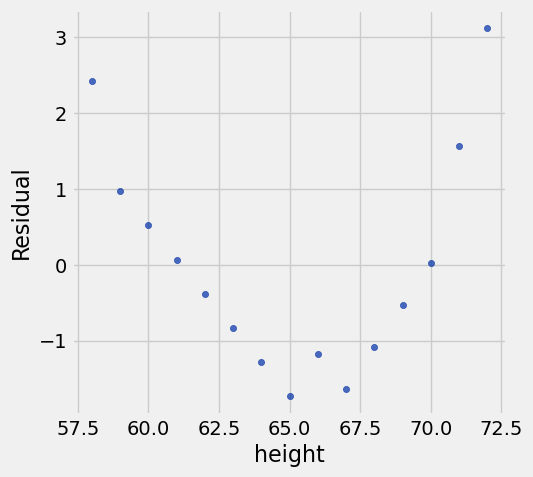

In [23]:
plot_residuals(us_women, 'height', 'ave weight')

***QUESTION: What do you notice about the data compared to the Regression Line?***



***QUESTION: What do you notice about the residual plot?***



***QUESTION: What might this indicate?***



## Average of Residuals ##

Since the residuals are centered around zero with some above and some below with basically no correlation, we expect the average of all of the residuals to equal to zero. 

Residuals from a linear regression always have
 * Zero mean (so rmse = sd of residuals)
 * Zero correlation with x
 * Zero correlation with the fitted values


These are all true no matter what the data look like
 * Just like deviations from mean are zero on average


In [25]:
# Check the residual average for the Dugong data

round(np.average(residuals(dugong, 'Length', 'Age')), 6)

0.0

In [26]:
# Check the residual average for the Child Height data

round(np.average(residuals(heights, 'MidParent', 'Child')), 6)

0.0

In [27]:
# Check the residual average for the Voting District data

round(np.average(residuals(demographics, 'College%', 'Median Income')), 6)

0.0

In [28]:
# Recall the parent average height, the child adult height with the fitted value and it's residual. 
heights = heights.with_columns(
    'Residual', residuals(heights, 'MidParent', 'Child'),
    'Fitted Value', fitted_values(heights, 'MidParent', 'Child')
)
heights

MidParent,Child,Residual,Fitted Value
75.43,73.2,2.48763,70.7124
75.43,69.2,-1.51237,70.7124
75.43,69,-1.71237,70.7124
75.43,69,-1.71237,70.7124
73.66,73.5,3.91576,69.5842
73.66,72.5,2.91576,69.5842
73.66,65.5,-4.08424,69.5842
73.66,65.5,-4.08424,69.5842
72.06,71,2.43553,68.5645
72.06,68,-0.564467,68.5645


In [29]:
# Check the correlation with the residuals and child height

correlation(heights, 'MidParent', 'Residual')


-2.7196898076470642e-16

In [30]:
# Check the correlation with the residuals and the fitted value

round(correlation(heights, 'Fitted Value', 'Residual'), 6)

-0.0

In [31]:
# Recall the correlation between the Parent avg height and the child's height. 
r_heights = correlation (heights, 'MidParent', 'Child')
r_heights

0.32094989606395924

### Notes on the Standard Deviation



In [32]:
# Compare the STD of the Residual to the rmse of the child heights. 

np.std(heights.column('Residual')), np.sqrt(1 - r_heights**2) * np.std(heights.column('Child'))

(3.3880799163953426, 3.3880799163953421)

In [33]:
# Recall the Voting District data with the district median income and percent who went to college 
# with the fitted value of the median income and its residual.
demographics_new

Median Income,College%,Fitted Value,Residual
47083,24,51299.4,-4216.42
42035,21.8,48503.9,-6468.87
46544,22.8,49774.6,-3230.58
41110,17,42404.5,-1294.51
51690,30.3,59304.8,-7614.84
61413,36.7,67437.3,-6024.33
34664,19.4,45454.2,-10790.2
76440,29.6,58415.3,18024.7
50537,24.5,51934.8,-1397.77
49072,34,64006.4,-14934.4


In [34]:
# Recall r for College and Median Income
r = correlation(demographics_new, 'College%', 'Median Income')
r

0.81846485171413352

In [35]:
# Check the correlation between the fitted value and the residual.

correlation(demographics_new, 'Fitted Value', 'Residual')

4.6144442034995009e-16

In [37]:
# Compare std of residual to the rmse for demographics Median Income. 

np.std(demographics_new.column('Residual')), np.sqrt(1 - r**2) * np.std(demographics_new.column('Median Income'))

(9398.5155885712829, 9398.5155885712848)

### Discussion Question ###

How would we adjust our regression line...

1. if the average residual were 10?
2. if the residuals were positively correlated with x?
3. if the residuals were above 0 in the middle and below 0 on the left and right?
 
**Residuals of 10:** ?

**Positively correlated:** ?

**Above and below 0 at the ends:** ?